In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [12]:
def est(t, x):
    # Parameters and constants
    cv = 0.1; D1 = 2.5; D2 = 3.0
    Dt = 0.3; F0 = 0; F2 = 0
    g = 9.8; h1max = 4.0; L = 100
    mu = 0.001; ro = 1000

    # Constitutive relations
    A1 = np.pi*(D1**2)/4
    A2 = np.pi*(D2**2)/4
    At = np.pi*(Dt**2)/4
    Re = Dt*ro*np.abs(x[2])/mu

    # Differential equations with tank overflow logic
    if x[0] >= h1max and x[2] < 0:
        dx1 = 0    # Tank 1 is full and cannot accept more liquid
    else:
        dx1 = (F0 - x[2]*At)/A1

    dx2 = (x[2]*At - F2)/A2
    dx3 = g/L*(x[0] - x[1])   # No friction term (negligible)
    return [dx1, dx2, dx3]

In [13]:
# Initial conditions and integration time
x0 = [2, 5, 1e-8]
t_span = (0, 500)
t = np.linspace(t_span[0], t_span[1], 1000)

# Integrate the differential equations
sol = solve_ivp(est, t_span, x0, t_eval=t, atol=1e-8, rtol=1e-8, method='RK45')

# Extract results
h1, h2, v1 = sol.y
datos = np.column_stack((t, sol.y.T))
np.savetxt('data_4d.txt', datos, delimiter=' ')

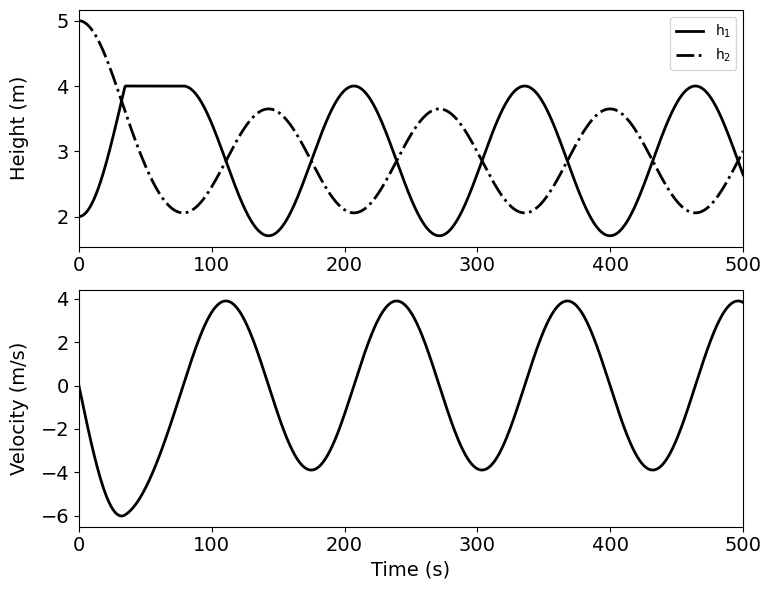

In [14]:
# Plot results
plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
plt.plot(t, h1, 'k', lw=2)
plt.plot(t, h2, 'k-.', lw=2)
plt.ylabel('Height (m)', fontsize=14, labelpad=20)
plt.legend(['h$_1$', 'h$_2$'], loc='upper right')
plt.xlim(0, 500)
plt.tick_params(axis='both', labelsize=14)

plt.subplot(2, 1, 2)
plt.plot(t, v1, 'k', lw=2)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Velocity (m/s)', fontsize=14, labelpad=8)
plt.xlim(0, 500)
plt.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

In [15]:
import os
print(os.getcwd)

<built-in function getcwd>
